Advertising and Sales

Data Fields:

TV -- amount spend on TV ads on sales in dollars.
radio -- amount spend on radio ads on sales in dollars.
newspaper -- amount spend on newspaper ads on sales in dollars.
sales --- sale in dollars.

In [36]:
#import import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

In [2]:
#import data file 
data = pd.read_csv("Advertising.csv")
data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
#data shape
data.shape

(200, 5)

In [4]:
#check for Null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
#univariate measures
data.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


<Axes: xlabel='newspaper', ylabel='sales'>

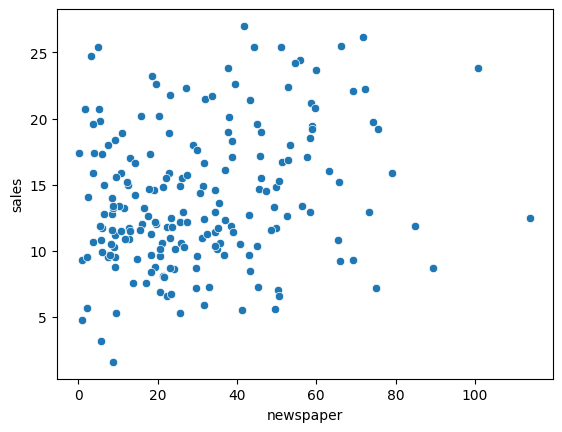

In [6]:
#visualize the data
sns.scatterplot(data=data, x="newspaper", y="sales")

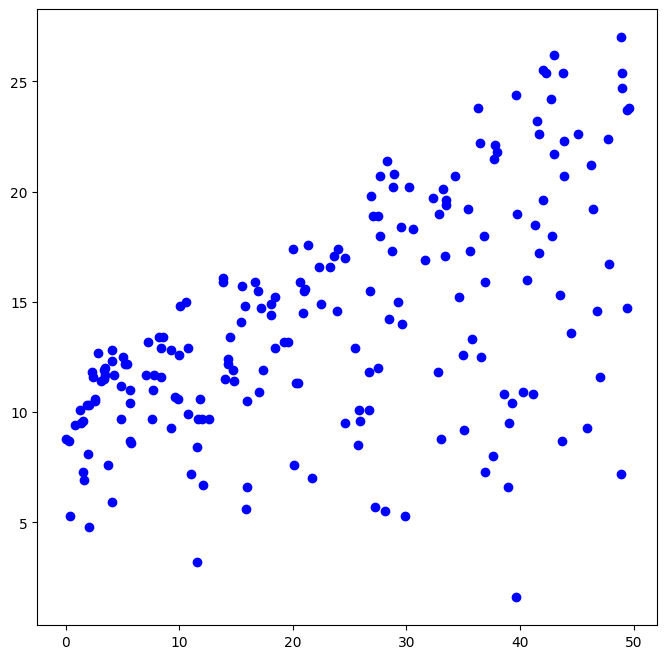

In [7]:
plt.figure(figsize=(8,8))
plt.scatter(data['radio'], data['sales'], c='b')
plt.show()

<Axes: xlabel='TV', ylabel='sales'>

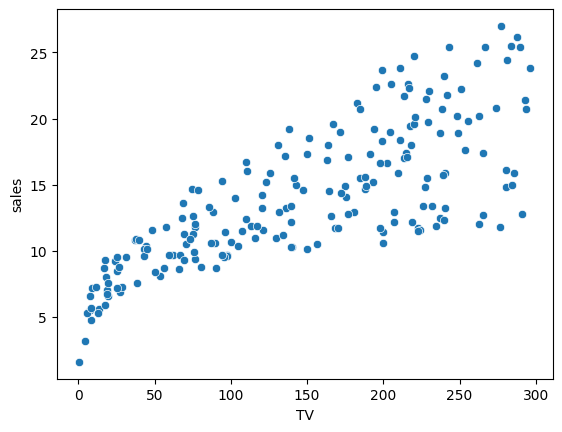

In [8]:
sns.scatterplot(data=data, x='TV', y='sales')

In [9]:
#check correlation
data_corr = data.corr()
data_corr

,Unnamed: 0,TV,radio,newspaper,sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
radio,-0.110680,0.054809,1.000000,0.354104,0.576223
newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
sales,-0.051616,0.782224,0.576223,0.228299,1.000000


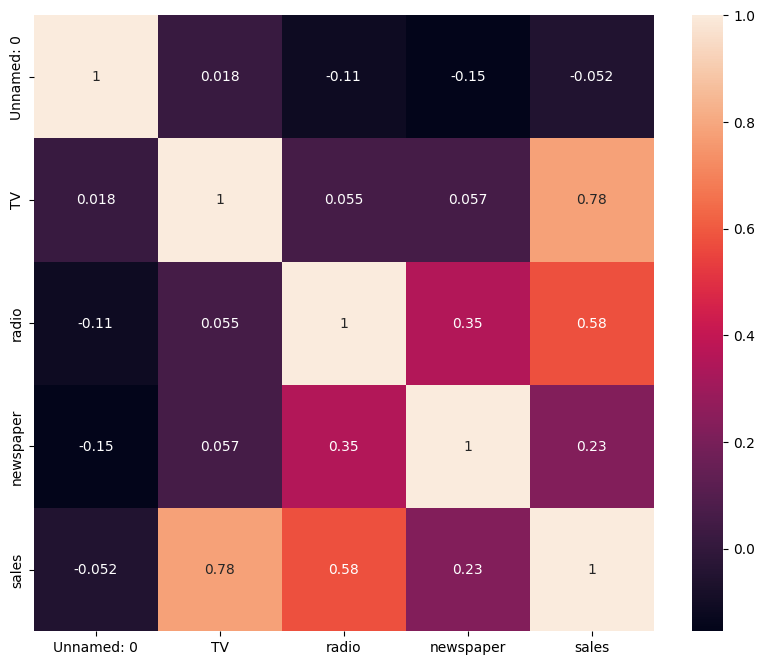

In [10]:
#heatmap
plt.subplots(figsize=(10, 8))
sns.heatmap(data_corr, annot=True)
plt.show()

Linear Regression Function
Creating a function for Linear Regression Model fit on the data

In [11]:
def Linear_regression(x_train, y_train):
    print("Linear Regression:")
    linear_regression = LinearRegression()
    linear_regression.fit(x_train, y_train)
    return linear_regression

Lasso Regression Function
Creating a function for Lasso Regression Model fit on the data

In [12]:
def Lasso_Regression(x_train, y_train):
    print("Lasso_Regression :")
    lasso_regression = Lasso(alpha=0.8, max_iter=1000)
    lasso_regression.fit(x_train, y_train)
    return lasso_regression

Ridge Regression Function
Creating a function for Ridge Regression Model fit on the data

In [13]:
def Ridge_Regression(x_train, y_train):
    print("Ridge_Regression :")
    ridge_Regression = Ridge(alpha=0.9)
    ridge_Regression.fit(x_train, y_train)
    return ridge_Regression


Sochastic Gradient Descent Regression
Creating a function for Sochastic Gradient Descent Regression Model fit on the data

In [37]:
def SGD_Regression(x_train, y_train):
    print("sgd_Regression :")
    sgd_Regression = SGDRegressor(max_iter=2000)
    sgd_Regression.fit(x_train, y_train)
    return sgd_Regression

Multilayer Preceptron Regresson
Creating a function for MLP Regressor Neural Network to fit the data. 3 Hidden layers, with 13 neurons each.

In [15]:
def MLP_Regressor(x_train, y_train):
    print("MLP Regressor: ")
    mlp_regressor = MLPRegressor(activation='relu', hidden_layer_sizes=(13,13,13), solver='lbfgs', verbose = True, max_iter= 20000)
    mlp_regressor.fit(x_train, y_train)
    return mlp_regressor

Build and Train Model Function
Creating a Function for building, training and evaluating the model by using the train test split method where X is all variables but the median value and Y is target name = sales. The function preprocesses the data using standard scaler, trains the model ans print out the r2 score for accuracy, with the predicted values vs actual values.

In [23]:
def build_and_train_model(data, target_name, reg_fn):
    X = data.drop(target_name, axis=1)
    Y = data[target_name]
    x_train, x_test, y_train, y_test = train_test_split(X, Y, shuffle=True, test_size=0.2)

    scaler = StandardScaler()
    scaler.fit(x_train)

    x_train = scaler.transform(x_train)

    x_test = scaler.transform(x_test)

    model = reg_fn(x_train, y_train)
    score = model.score(x_train, y_train)
    print("Training score: ", score)

    y_pred = model.predict(x_test)
    r_score = r2_score(y_test, y_pred)
    print("Testing Score : ", r_score)

    df_y = pd.DataFrame({'y_test' : y_test, 'y_pred' : y_pred})
    print(df_y.sample(10))
    plt.figure(figsize=(10, 8))

    plt.plot(y_pred, label='Predicted')
    plt.plot(y_test.values, label='Actual')
    plt.ylabel("medv of home")
    plt.legend()
    plt.show()

    return{'model' : model, 
            'x_train' : x_train, 'x_test' : x_test,
            'y_train' : y_train, 'y_test' : y_test, 
            'y_pred' : y_pred, 'sample' : df_y.sample(10)
            }

Linear Regression Model fit Results
Utilizing the build and train model function to predict and score the Linear Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values

Linear Regression:
Training score:  0.8907760684826369
Testing Score :  0.9091119598564387
     y_test     y_pred
141    19.2  18.214632
59     18.4  18.124761
0      22.1  20.320115
199    13.4  15.286273
109    19.8  19.691458
135    11.6  13.959686
168    17.1  17.104845
72      8.8  10.391090
23     15.5  16.565703
55     23.7  21.055030


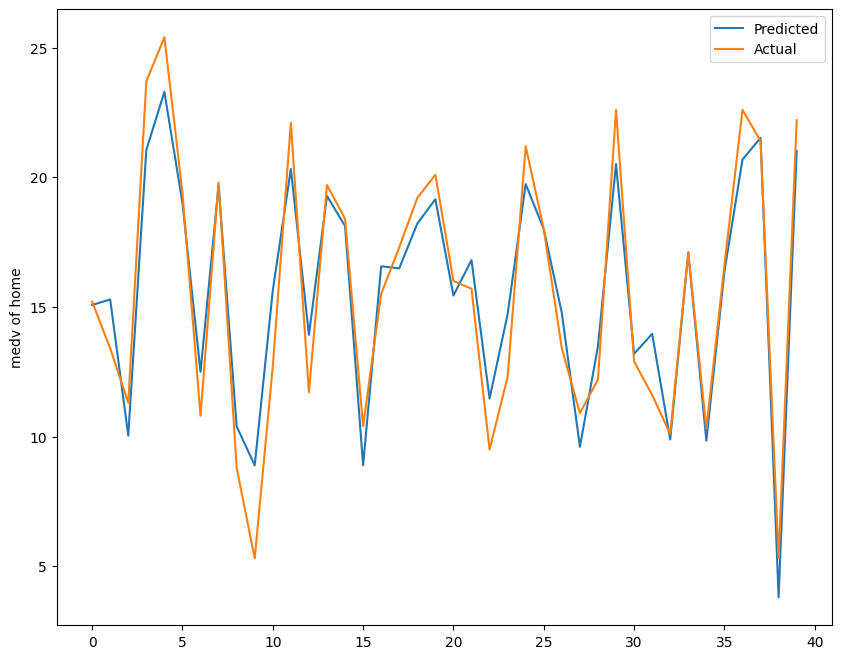

In [28]:
Linear_regression = build_and_train_model(data, "sales", Linear_regression)

Lasso Regression Model fit results
Utilizing the build and train model function to predict and score the Lasso Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

Lasso_Regression :
Training score:  0.8512824446024585
Testing Score :  0.8771545029357689
     y_test     y_pred
55     23.7  19.511667
94     11.5  11.247233
187    17.3  16.392012
136     9.5  11.596109
86     12.0  11.925548
171    14.5  14.329710
177    11.7  12.754068
181    12.2  14.236486
74     17.0  16.667787
20     18.0  17.278596


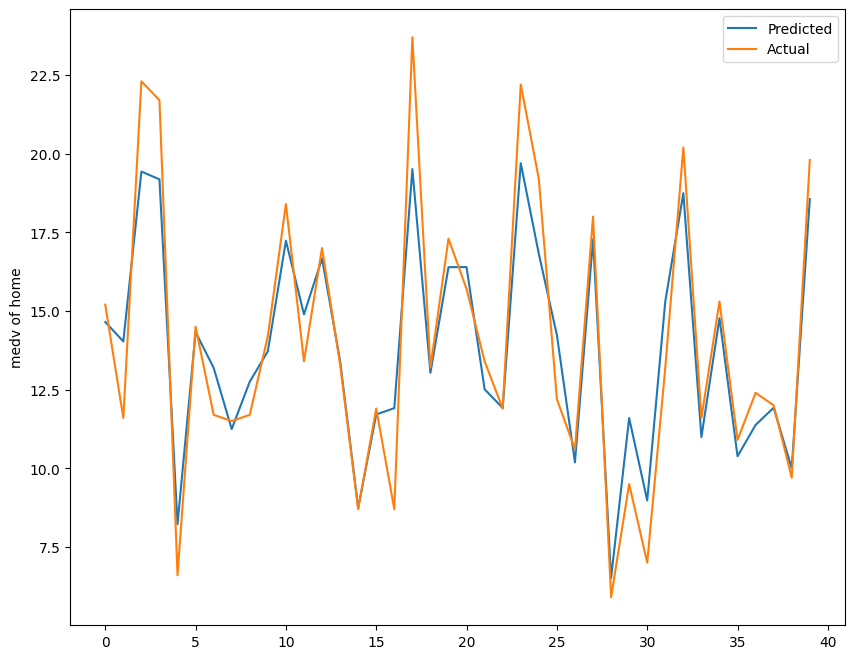

In [29]:

Lasso_regression = build_and_train_model(data, "sales", Lasso_Regression)

Ridge Regression Model fit results
Utilizing the build and train model function to predict and score the Ridge Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

Ridge_Regression :
Training score:  0.8987509306914957
Testing Score :  0.8882841079816373
     y_test     y_pred
153    19.0  18.183477
94     11.5  10.361992
162    14.9  14.775783
5       7.2  12.705079
2       9.3  12.514876
146    13.2  15.056826
7      13.2  12.113505
108     5.3   3.424348
6      11.8  11.812578
149    10.1   9.735167


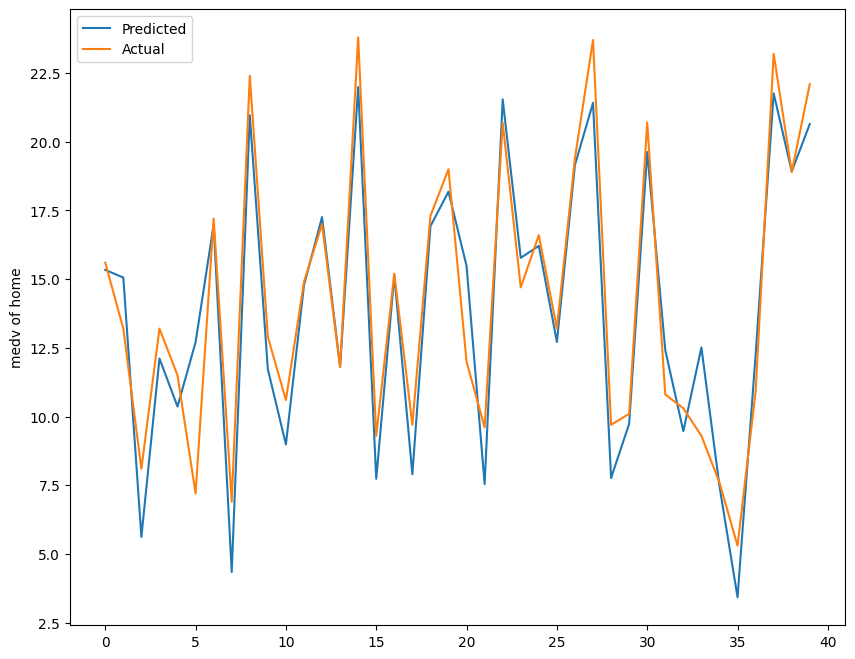

In [30]:

Ridge_regression = build_and_train_model(data, "sales", Ridge_Regression)

Sochastic Gradient Descent Regression Model fit results
Utilizing the build and train model function to predict and score the Sochastic Gradient Descent Regression algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

sgd_Regression :
Training score:  0.901132901508479
Testing Score :  0.8805120546675786
     y_test     y_pred
3      18.5  17.734856
135    11.6  13.954185
84     21.7  20.812169
125    10.6   9.111144
193    19.6  18.395106
137    20.8  20.941360
131    12.7  15.594291
118    15.9  15.746454
17     24.4  23.336010
100    11.7  13.927502


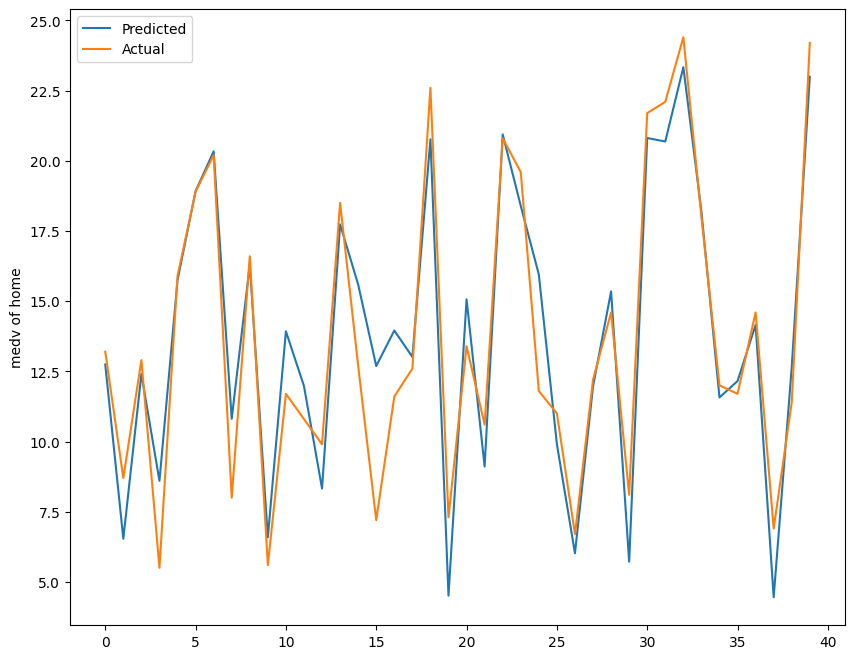

In [38]:
SGD_regression = build_and_train_model(data, "sales", SGD_Regression)


Multilayer Preceptron Regression Neural Network model fit results
Utilizing the build and train model function to predict and score the Multilayer Preceptron Regression Neural Network algorithm on the data. 3 inputs as needed: data file, value to predict(price), and the type of model below. Results in order Training score, Testing/r2 score to predict accuracy, and the Y_test: actual values and Y_pred = predicted values.

MLP Regressor: 
Training score:  0.9990054389132524
Testing Score :  0.9891444213594361
     y_test     y_pred
194    17.3  17.101264
90     11.2  10.897023
193    19.6  19.457271
3      18.5  18.554314
15     22.4  22.571595
196     9.7   9.566247
89     16.7  16.484201
132     5.7   5.248534
16     12.5  11.659326
115    12.6  12.658886


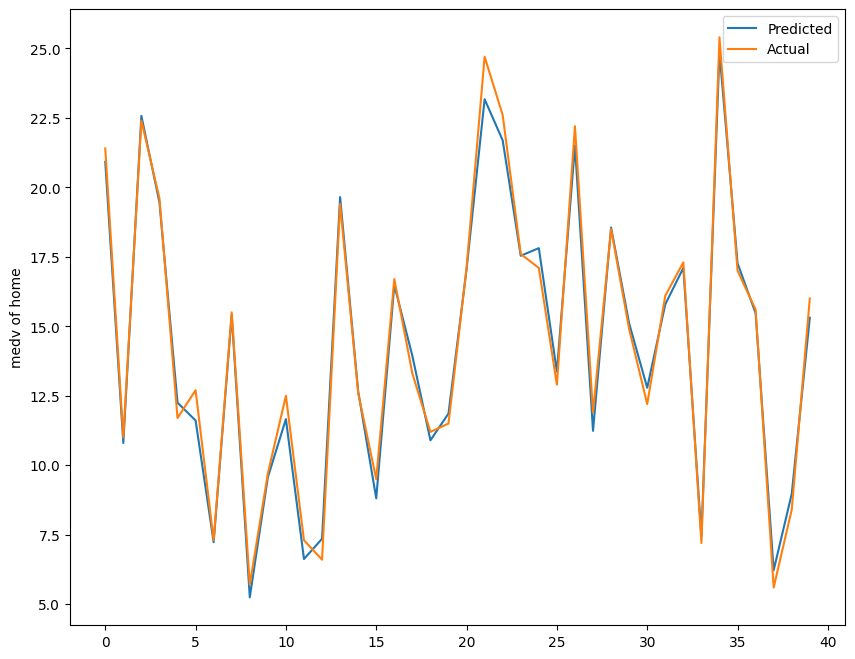

In [39]:
MLP_Regression = build_and_train_model(data, "sales", MLP_Regressor)